In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("Processed_data/Master_data_Ecommerce.csv")
df.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,9.0,14.0,cool_stuff,27277,volta redonda,SP,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,30.0,40.0,pet_shop,3471,sao paulo,SP,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,13.0,33.0,furniture_decor,37564,borda da mata,MG,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114977 entries, 0 to 114976
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114977 non-null  object 
 1   order_item_id                  114977 non-null  int64  
 2   product_id                     114977 non-null  object 
 3   seller_id                      114977 non-null  object 
 4   shipping_limit_date            114977 non-null  object 
 5   price                          114977 non-null  float64
 6   freight_value                  114977 non-null  float64
 7   customer_id                    114977 non-null  object 
 8   order_status                   114977 non-null  object 
 9   order_purchase_timestamp       114977 non-null  object 
 10  order_approved_at              114962 non-null  object 
 11  order_delivered_carrier_date   114977 non-null  object 
 12  order_delivered_customer_date 

In [4]:
customer_dataset = pd.read_csv("Raw_Data/olist_customers_dataset.csv")
product_dataset = pd.read_csv("Raw_Data/olist_products_dataset.csv")
seller_dataset = pd.read_csv("Raw_Data/olist_sellers_dataset.csv")
product_category_name = pd.read_csv("Raw_Data/product_category_name_translation.csv")

In [5]:
customer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [6]:
customer_dataset.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [7]:
dfs = [product_dataset, seller_dataset, product_category_name]

for i, df in enumerate(dfs, start=1):
    print(f"\n===== df{i} =====")
    df.info()


===== df1 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

===== df2 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------          

In [8]:
cols_to_drop = [
    'product_name_lenght',
    'product_description_lenght'
]

product_dataset.drop(columns=cols_to_drop,inplace = True)

In [9]:
product_dataset = product_dataset.merge(
    product_category_name,
    on="product_category_name",
    how="left"
)

In [10]:
product_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32341 non-null  object 
 2   product_photos_qty             32341 non-null  float64
 3   product_weight_g               32949 non-null  float64
 4   product_length_cm              32949 non-null  float64
 5   product_height_cm              32949 non-null  float64
 6   product_width_cm               32949 non-null  float64
 7   product_category_name_english  32328 non-null  object 
dtypes: float64(5), object(3)
memory usage: 2.0+ MB


In [11]:
product_dataset.drop('product_photos_qty',axis = 1, inplace = True)

In [12]:
product_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32341 non-null  object 
 2   product_weight_g               32949 non-null  float64
 3   product_length_cm              32949 non-null  float64
 4   product_height_cm              32949 non-null  float64
 5   product_width_cm               32949 non-null  float64
 6   product_category_name_english  32328 non-null  object 
dtypes: float64(4), object(3)
memory usage: 1.8+ MB


In [13]:
Master_data_Ecommerce = pd.read_csv("Processed_data/Master_data_Ecommerce.csv")
Master_data_Ecommerce = Master_data_Ecommerce.merge(
    product_dataset,
    on="product_id",
    how="left"
)

In [14]:
Master_data_Ecommerce = Master_data_Ecommerce.merge(
    seller_dataset,
    on="seller_id",
    how="left"
)

In [15]:
Master_data_Ecommerce = Master_data_Ecommerce.merge(
    customer_dataset,
    on="customer_id",
    how="left"
)

In [16]:
Master_data_Ecommerce.to_csv('C:/Users/ASMIT/OneDrive/Desktop/Master_data_Ecommerce/data/processed/Master_data_Ecommerce.csv', index = False)

In [17]:
df = pd.read_csv("Processed_data/Master_data_Ecommerce.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114977 entries, 0 to 114976
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114977 non-null  object 
 1   order_item_id                  114977 non-null  int64  
 2   product_id                     114977 non-null  object 
 3   seller_id                      114977 non-null  object 
 4   shipping_limit_date            114977 non-null  object 
 5   price                          114977 non-null  float64
 6   freight_value                  114977 non-null  float64
 7   customer_id                    114977 non-null  object 
 8   order_status                   114977 non-null  object 
 9   order_purchase_timestamp       114977 non-null  object 
 10  order_approved_at              114962 non-null  object 
 11  order_delivered_carrier_date   114977 non-null  object 
 12  order_delivered_customer_date 

### *DATA CLEANING*

In [18]:
required_cols = [
    'order_id','order_item_id','shipping_limit_date','price','freight_value','order_purchase_timestamp','order_approved_at','order_status',
    'order_estimated_delivery_date','order_delivered_customer_date','review_score','delivery_delay_days','delay_days','has_review','risk_type',
    'purchase_approved_gap','approved_shipped_gap','courier_risk_flag','payment_type','payment_installments','payment_value','delay_bucket',
    'product_category_name_english','product_weight_g','product_length_cm','product_height_cm','product_width_cm',
    'seller_id','seller_zip_code_prefix','seller_city','seller_state',
    'customer_zip_code_prefix','customer_city','customer_state'
]

df = df[required_cols]

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114977 entries, 0 to 114976
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114977 non-null  object 
 1   order_item_id                  114977 non-null  int64  
 2   shipping_limit_date            114977 non-null  object 
 3   price                          114977 non-null  float64
 4   freight_value                  114977 non-null  float64
 5   order_purchase_timestamp       114977 non-null  object 
 6   order_approved_at              114962 non-null  object 
 7   order_status                   114977 non-null  object 
 8   order_estimated_delivery_date  114977 non-null  object 
 9   order_delivered_customer_date  114977 non-null  object 
 10  review_score                   114116 non-null  float64
 11  delivery_delay_days            114977 non-null  float64
 12  delay_days                    

In [20]:
ColsToDrop = ['order_id', 'order_item_id', 'seller_id', 'customer_city', 'seller_city', 'delay_bucket', 'delay_days']
df.drop(columns=ColsToDrop,axis = 1,inplace = True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114977 entries, 0 to 114976
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   shipping_limit_date            114977 non-null  object 
 1   price                          114977 non-null  float64
 2   freight_value                  114977 non-null  float64
 3   order_purchase_timestamp       114977 non-null  object 
 4   order_approved_at              114962 non-null  object 
 5   order_status                   114977 non-null  object 
 6   order_estimated_delivery_date  114977 non-null  object 
 7   order_delivered_customer_date  114977 non-null  object 
 8   review_score                   114116 non-null  float64
 9   delivery_delay_days            114977 non-null  float64
 10  has_review                     114977 non-null  object 
 11  risk_type                      114977 non-null  object 
 12  purchase_approved_gap         

In [22]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 14 numerical features : ['price', 'freight_value', 'review_score', 'delivery_delay_days', 'purchase_approved_gap', 'approved_shipped_gap', 'payment_installments', 'payment_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'customer_zip_code_prefix']

We have 13 categorical features : ['shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at', 'order_status', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'has_review', 'risk_type', 'courier_risk_flag', 'payment_type', 'product_category_name_english', 'seller_state', 'customer_state']


In [23]:
df.to_csv("ML_Dataset.csv",index = False)

In [24]:
df = pd.read_csv("ML_Dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114977 entries, 0 to 114976
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   shipping_limit_date            114977 non-null  object 
 1   price                          114977 non-null  float64
 2   freight_value                  114977 non-null  float64
 3   order_purchase_timestamp       114977 non-null  object 
 4   order_approved_at              114962 non-null  object 
 5   order_status                   114977 non-null  object 
 6   order_estimated_delivery_date  114977 non-null  object 
 7   order_delivered_customer_date  114977 non-null  object 
 8   review_score                   114116 non-null  float64
 9   delivery_delay_days            114977 non-null  float64
 10  has_review                     114977 non-null  object 
 11  risk_type                      114977 non-null  object 
 12  purchase_approved_gap         

In [25]:
df.isnull().sum()

shipping_limit_date                 0
price                               0
freight_value                       0
order_purchase_timestamp            0
order_approved_at                  15
order_status                        0
order_estimated_delivery_date       0
order_delivered_customer_date       0
review_score                      861
delivery_delay_days                 0
has_review                          0
risk_type                           0
purchase_approved_gap              15
approved_shipped_gap               15
courier_risk_flag                   0
payment_type                        3
payment_installments                3
payment_value                       3
product_category_name_english    1650
product_weight_g                   20
product_length_cm                  20
product_height_cm                  20
product_width_cm                   20
seller_zip_code_prefix              0
seller_state                        0
customer_zip_code_prefix            0
customer_sta

### *CHECK AND REMOVE DUPLICATE FROM DATASET*

In [26]:
df.duplicated().sum()

11191

In [27]:
df[df.duplicated()].head(3)

,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_approved_at,order_status,order_estimated_delivery_date,order_delivered_customer_date,review_score,delivery_delay_days,...,payment_value,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_state,customer_zip_code_prefix,customer_state
14,2018-02-21 02:55:52,49.90,13.37,2018-02-13 22:10:21,2018-02-15 03:55:52,delivered,2018-03-06,2018-02-26 13:55:22,5.0,-8.0,...,126.54,garden_tools,1650.0,30.0,22.0,30.0,15025,SP,6600,SP
33,2017-10-20 16:07:52,21.33,15.10,2017-10-16 15:29:43,2017-10-16 16:07:52,delivered,2017-11-06,2017-10-27 18:43:56,NaN,-10.0,...,109.29,sports_leisure,180.0,17.0,11.0,14.0,18055,SP,74663,GO
34,2017-10-20 16:07:52,21.33,15.10,2017-10-16 15:29:43,2017-10-16 16:07:52,delivered,2017-11-06,2017-10-27 18:43:56,NaN,-10.0,...,109.29,sports_leisure,180.0,17.0,11.0,14.0,18055,SP,74663,GO


In [28]:
df.duplicated(keep=False).sum()

18877

In [29]:
df = df.drop_duplicates()
df.duplicated().sum()

0

In [30]:
df.isnull().sum()

shipping_limit_date                 0
price                               0
freight_value                       0
order_purchase_timestamp            0
order_approved_at                  14
order_status                        0
order_estimated_delivery_date       0
order_delivered_customer_date       0
review_score                      718
delivery_delay_days                 0
has_review                          0
risk_type                           0
purchase_approved_gap              14
approved_shipped_gap               14
courier_risk_flag                   0
payment_type                        1
payment_installments                1
payment_value                       1
product_category_name_english    1478
product_weight_g                   17
product_length_cm                  17
product_height_cm                  17
product_width_cm                   17
seller_zip_code_prefix              0
seller_state                        0
customer_zip_code_prefix            0
customer_sta

In [31]:
df['order_status'].value_counts()

order_status
delivered    103779
canceled          7
Name: count, dtype: int64

### *HANDLING NULL VALUES*

In [32]:
df['review_score'] = df['review_score'].fillna(df['review_score'].median())

In [33]:
print(df['review_score'].median())

5.0


<Axes: ylabel='review_score'>

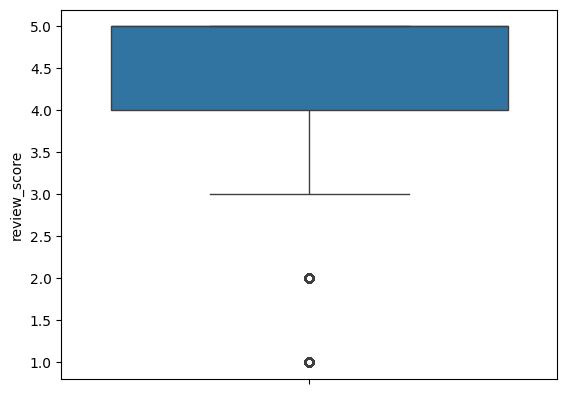

In [34]:
sns.boxplot(df['review_score'])

In [35]:
df['purchase_approved_gap'] = df['purchase_approved_gap'].fillna(df['purchase_approved_gap'].median())

In [36]:
df['approved_shipped_gap'] = df['approved_shipped_gap'].fillna(df['approved_shipped_gap'].median())

In [37]:
payment_cols = [
    "payment_type",
    "payment_installments",
    "payment_value"
]

df = df.dropna(subset=payment_cols)

In [38]:
df = df.copy()

df.loc[:, "product_category_name_english"] = (
    df["product_category_name_english"].str.strip()
)

In [39]:
dimension_cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in dimension_cols:
    df[col] = df[col].fillna(df[col].median())

In [40]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at"
    # only include columns that ACTUALLY exist
]

df[df[date_cols].isna().any(axis=1)]

,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_approved_at,order_status,order_estimated_delivery_date,order_delivered_customer_date,review_score,delivery_delay_days,...,payment_value,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_state,customer_zip_code_prefix,customer_state
8336,2017-02-21 12:05:55,79.99,15.77,2017-02-17 13:05:55,NaN,delivered,2017-03-20,2017-03-02 11:09:19,5.0,-18.0,...,95.76,cool_stuff,1200.0,42.0,25.0,15.0,3426,SP,27945,RJ
19430,2017-02-22 16:15:03,79.99,26.82,2017-02-18 17:15:03,NaN,delivered,2017-03-31,2017-03-03 18:43:43,4.0,-28.0,...,106.81,cool_stuff,1200.0,42.0,25.0,15.0,3426,SP,65110,MA
20904,2017-02-21 16:21:55,135.00,19.23,2017-02-17 17:21:55,NaN,delivered,2017-03-20,2017-03-03 12:16:03,5.0,-17.0,...,154.23,garden_tools,4300.0,36.0,13.0,20.0,3554,SP,35620,MG
26966,2017-02-22 14:53:27,133.99,23.20,2017-02-17 15:53:27,NaN,delivered,2017-03-23,2017-03-03 11:47:47,3.0,-20.0,...,157.19,bed_bath_table,2700.0,42.0,11.0,36.0,14940,SP,95795,RS
36989,2017-02-28 14:52:27,59.90,17.16,2017-02-18 15:52:27,NaN,delivered,2017-03-29,2017-03-07 13:57:47,5.0,-22.0,...,77.06,furniture_decor,1200.0,30.0,5.0,20.0,14940,SP,37660,MG
41793,2017-02-22 15:48:35,79.99,26.82,2017-02-18 16:48:35,NaN,delivered,2017-03-31,2017-03-09 07:28:47,5.0,-22.0,...,106.81,cool_stuff,1200.0,42.0,25.0,15.0,3426,SP,62700,CE
50474,2017-01-29 22:26:59,45.90,14.52,2017-01-19 22:26:59,NaN,delivered,2017-03-16,2017-02-06 14:22:19,2.0,-32.0,...,60.42,furniture_decor,600.0,30.0,3.0,20.0,14940,SP,36400,MG
50502,2017-02-22 12:29:47,49.99,15.53,2017-02-18 13:29:47,NaN,delivered,2017-03-17,2017-03-01 08:07:38,5.0,-16.0,...,65.52,NaN,3100.0,28.0,28.0,50.0,13360,SP,8230,SP
61022,2017-02-22 21:49:19,49.00,14.52,2017-02-18 22:49:19,NaN,delivered,2017-03-21,2017-03-02 12:06:06,4.0,-19.0,...,127.04,telephony,250.0,18.0,3.0,28.0,11010,SP,21020,RJ
62206,2017-02-22 11:45:31,379.00,17.86,2017-02-18 12:45:31,NaN,delivered,2017-03-21,2017-03-02 10:05:06,5.0,-19.0,...,396.86,construction_tools_safety,1008.0,33.0,14.0,26.0,88090,SC,93548,RS


In [41]:
df.dropna(subset=["order_approved_at"], inplace=True)

In [42]:
df.isnull().sum()

shipping_limit_date                 0
price                               0
freight_value                       0
order_purchase_timestamp            0
order_approved_at                   0
order_status                        0
order_estimated_delivery_date       0
order_delivered_customer_date       0
review_score                        0
delivery_delay_days                 0
has_review                          0
risk_type                           0
purchase_approved_gap               0
approved_shipped_gap                0
courier_risk_flag                   0
payment_type                        0
payment_installments                0
payment_value                       0
product_category_name_english    1477
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
seller_zip_code_prefix              0
seller_state                        0
customer_zip_code_prefix            0
customer_sta

### *HANDLING DATE & TIME COLUMN*

In [43]:
df.groupby("order_status")[["order_approved_at"]].apply(lambda x: x.isna().sum())

,order_approved_at
order_status,
canceled,0
delivered,0


In [44]:
df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

In [45]:
df["delivery_days"] = (
    df["order_delivered_customer_date"]
    - df["order_purchase_timestamp"]
).dt.days

In [46]:
df["delivery_anomaly"] = (
    (df["delivery_days"] < 0) |
    (df["delivery_days"] > 100)
)

In [47]:
df["invalid_timeline"] = (
    (df["order_approved_at"] < df["order_purchase_timestamp"]) |
    (df["order_delivered_customer_date"] < df["order_purchase_timestamp"])
)

In [48]:
df["delivery_anomaly"].value_counts()

delivery_anomaly
False    103702
True         69
Name: count, dtype: int64

In [49]:
df.drop(columns=[
    "shipping_limit_date",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "order_delivered_customer_date"
], inplace=True)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103771 entries, 0 to 114976
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   price                          103771 non-null  float64
 1   freight_value                  103771 non-null  float64
 2   order_status                   103771 non-null  object 
 3   review_score                   103771 non-null  float64
 4   delivery_delay_days            103771 non-null  float64
 5   has_review                     103771 non-null  object 
 6   risk_type                      103771 non-null  object 
 7   purchase_approved_gap          103771 non-null  float64
 8   approved_shipped_gap           103771 non-null  float64
 9   courier_risk_flag              103771 non-null  object 
 10  payment_type                   103771 non-null  object 
 11  payment_installments           103771 non-null  float64
 12  payment_value                  1037

### *DATA ENCODING*

In [51]:
## Update the column "Delivery_delay_days"
df['delay_days_category'] = df['delivery_delay_days'].apply(
    lambda x: "VERY_LATE" if x > 10
    else "LATE" if x > 0
    else "EARLY" if x < 0
    else "ON_TIME"
)

In [52]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 17 numerical features : ['price', 'freight_value', 'review_score', 'delivery_delay_days', 'purchase_approved_gap', 'approved_shipped_gap', 'payment_installments', 'payment_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'customer_zip_code_prefix', 'delivery_days', 'delivery_anomaly', 'invalid_timeline']

We have 9 categorical features : ['order_status', 'has_review', 'risk_type', 'courier_risk_flag', 'payment_type', 'product_category_name_english', 'seller_state', 'customer_state', 'delay_days_category']


In [53]:
top25_categories = (
    df["product_category_name_english"]
    .value_counts()
    .nlargest(20)
    .index
)
df["product_category_name_english"] = df["product_category_name_english"].where(
    df["product_category_name_english"].isin(top25_categories),
    "Others"
)

In [54]:
df["product_category_name_english"].value_counts()

product_category_name_english
Others                      13265
bed_bath_table              10509
health_beauty                9020
sports_leisure               7890
computers_accessories        6931
furniture_decor              6893
housewares                   6173
watches_gifts                5833
telephony                    4309
auto                         4017
toys                         4014
cool_stuff                   3735
garden_tools                 3680
perfumery                    3270
baby                         2957
electronics                  2600
stationery                   2399
fashion_bags_accessories     2030
pet_shop                     1816
office_furniture             1336
luggage_accessories          1094
Name: count, dtype: int64

### *LABEL ENCODING*

In [55]:
df_ml = df.copy()

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_ml["order_status"] = le.fit_transform(df_ml["order_status"])
df_ml["has_review"] = le.fit_transform(df_ml["has_review"])

In [63]:
df_ml["seller_state"] = le.fit_transform(df_ml["seller_state"])
df_ml["customer_state"] = le.fit_transform(df_ml["customer_state"])

### *ORDINAL ENCODING*

In [57]:
df_ml['risk_type'].unique()

array(['NORMAL', 'VISIBLE_FAILURE', 'SILENT_RISK'], dtype=object)

In [58]:
df_ml['courier_risk_flag'].unique()

array(['NORMAL', 'HIGH_RISK'], dtype=object)

In [59]:
df_ml.delay_days_category.unique()

array(['EARLY', 'ON_TIME', 'LATE', 'VERY_LATE'], dtype=object)

In [60]:
risk_type_order = {
    "NORMAL": 1,
    "SILENT_RISK": 2,
    "VISIBLE_FAILURE": 3
}

df_ml["risk_type"] = df_ml["risk_type"].map(risk_type_order)

In [61]:
courier_risk_map = {
    "NORMAL": 0,
    "HIGH_RISK": 1
}

df_ml["courier_risk_flag"] = df_ml["courier_risk_flag"].map(courier_risk_map)

In [62]:
delay_days_category_oreder={
    "EARLY" : 1,
    "ON_TIME" : 2,
    "LATE" : 3,
    "VERY_LATE" : 4
}
df_ml["delay_days_category"] = df_ml["delay_days_category"].map(delay_days_category_oreder)

### *ONE HOT ENCODING*

In [64]:
df_ml = pd.get_dummies(
    df_ml,
    columns=["payment_type"],
    drop_first=True
)

In [65]:
df_ml = pd.get_dummies(
    df_ml,
    columns=["product_category_name_english"],
    drop_first=True
)

### *LOAD THE ML READY DATASET*

In [66]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103771 entries, 0 to 114976
Data columns (total 47 columns):
 #   Column                                                  Non-Null Count   Dtype  
---  ------                                                  --------------   -----  
 0   price                                                   103771 non-null  float64
 1   freight_value                                           103771 non-null  float64
 2   order_status                                            103771 non-null  int32  
 3   review_score                                            103771 non-null  float64
 4   delivery_delay_days                                     103771 non-null  float64
 5   has_review                                              103771 non-null  int32  
 6   risk_type                                               103771 non-null  int64  
 7   purchase_approved_gap                                   103771 non-null  float64
 8   approved_shipped_gap         

In [67]:
df_ml.to_csv("Processed_data/ML_ready_dataset.csv", index = False)

In [68]:
df_ml.to_csv('C:/Users/ASMIT/OneDrive/Desktop/Master_data_Ecommerce/data/processed/ML_ready_dataset.csv', index = False)